Saved Fig. S4 to:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_s4_prompt_composition_evolution.png


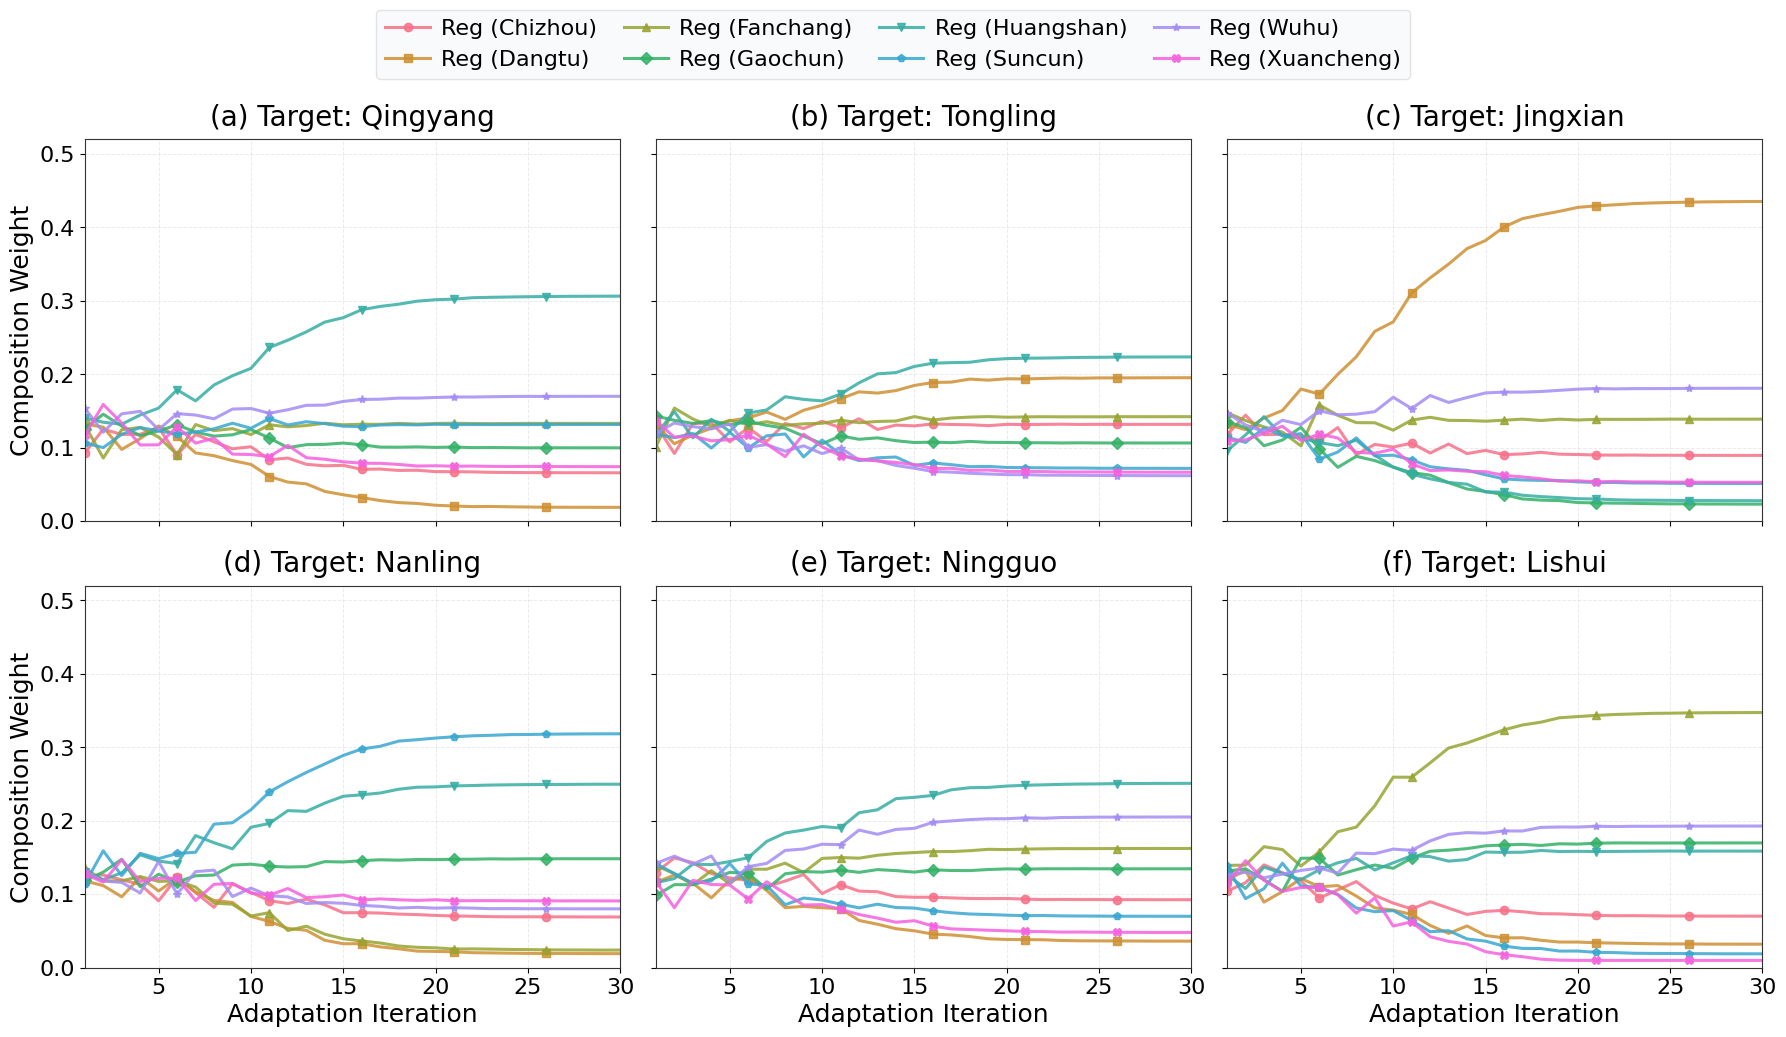

In [27]:
#!/usr/bin/env python3
"""
Fig. S4: Source-Prompt Composition Weight Evolution

Configuration:
  - 6 target regions
  - 8 source-region prompts
  - 2 × 3 subplot layout
  - Times New Roman
  - Regular font weight
  - Title: 20 pt
  - Axis labels: 18 pt
  - Tick labels and legend: 16 pt
  - PNG only, 300 dpi
"""

from pathlib import Path
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns


# =============================================================================
# 1. Global configuration
# =============================================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",

    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman",

    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False,
})

SAVE_DPI = 300

TITLE_FONTSIZE = 20
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

OUTPUT_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# 2. Region labels
# =============================================================================

# 6 target regions
TARGET_REGIONS = [
    ("04_Qingyang", "Qingyang"),
    ("06_Tongling", "Tongling"),
    ("08_Jingxian", "Jingxian"),
    ("10_Nanling", "Nanling"),
    ("11_Ningguo", "Ningguo"),
    ("12_Lishui", "Lishui"),
]

# 8 source-region prompts
SOURCE_REGION_NAMES = [
    "Reg (Chizhou)",
    "Reg (Dangtu)",
    "Reg (Fanchang)",
    "Reg (Gaochun)",
    "Reg (Huangshan)",
    "Reg (Suncun)",
    "Reg (Wuhu)",
    "Reg (Xuancheng)",
]


# =============================================================================
# 3. Plot
# =============================================================================

def generate_fig_s4_prompt_evolution() -> None:
    """Plot source-prompt composition weight evolution."""

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(18, 11),
        sharex=True,
        sharey=True,
    )

    axes = axes.ravel()

    iterations = np.arange(1, 31)
    num_sources = len(SOURCE_REGION_NAMES)

    colors = sns.color_palette("husl", num_sources)
    markers = ["o", "s", "^", "D", "v", "p", "*", "X"]

    np.random.seed(2026)

    for idx, (_, region_name) in enumerate(TARGET_REGIONS):
        ax = axes[idx]

        raw_weights = np.zeros(
            (len(iterations), num_sources)
        )

        target_bias = np.random.dirichlet(
            np.ones(num_sources) * 1.5
        )

        for t_idx, iteration in enumerate(iterations):
            progress = 1.0 / (
                1.0 + np.exp(-0.35 * (iteration - 10))
            )

            weights = (
                (1.0 - progress) * (1.0 / num_sources)
                + progress * target_bias
            )

            noise = np.random.normal(
                loc=0.0,
                scale=0.015 * (1.0 - progress),
                size=num_sources,
            )

            weights = np.clip(
                weights + noise,
                0.01,
                0.99,
            )

            raw_weights[t_idx] = (
                weights / weights.sum()
            )

        for source_idx in range(num_sources):
            ax.plot(
                iterations,
                raw_weights[:, source_idx],
                label=SOURCE_REGION_NAMES[source_idx],
                color=colors[source_idx],
                linewidth=2.2,
                marker=markers[source_idx],
                markevery=5,
                markersize=6,
                alpha=0.85,
            )

        ax.set_title(
            f"({chr(97 + idx)}) Target: {region_name}",
            fontsize=TITLE_FONTSIZE,
            fontweight="normal",
            pad=10,
        )

        ax.set_xlim(1, 30)
        ax.set_ylim(0.0, 0.52)

        ax.xaxis.set_major_locator(
            ticker.MultipleLocator(5)
        )
        ax.yaxis.set_major_locator(
            ticker.MultipleLocator(0.1)
        )

        ax.tick_params(
            axis="both",
            labelsize=TICK_FONTSIZE,
        )

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.4,
            color="#cccccc",
        )

        if idx >= 3:
            ax.set_xlabel(
                r"Adaptation Iteration",
                fontsize=LABEL_FONTSIZE,
                fontweight="normal",
            )

        if idx % 3 == 0:
            ax.set_ylabel(
                r"Composition Weight",
                fontsize=LABEL_FONTSIZE,
                fontweight="normal",
            )

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.95),
        ncol=4,
        frameon=True,
        facecolor="#f8f9fa",
        edgecolor="#dddddd",
        fontsize=LEGEND_FONTSIZE,
        columnspacing=1.2,
        handlelength=2.0,
        handletextpad=0.5,
    )

    fig.tight_layout(
        rect=[0.0, 0.0, 1.0, 0.87],
        pad=1.2,
    )

    output_path = (
        OUTPUT_DIR
        / "fig_s4_prompt_composition_evolution.png"
    )

    fig.savefig(
        output_path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    print(f"Saved Fig. S4 to:\n{output_path}")

    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    generate_fig_s4_prompt_evolution()

In [1]:
#!/usr/bin/env python3
"""
Fig. S4: Source-Prompt Composition Weight Evolution

Configuration:
  - 6 target regions
  - 8 source-region prompts
  - 3 × 2 subplot layout
  - Times New Roman
  - Regular font weight
  - Title: 20 pt
  - Axis labels: 18 pt
  - Tick labels and legend: 16 pt
  - PNG only, 300 dpi
"""

from pathlib import Path
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns


# =============================================================================
# 1. Global configuration
# =============================================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",

    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman",

    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False,
})

SAVE_DPI = 300

TITLE_FONTSIZE = 20
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16

OUTPUT_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# 2. Region labels
# =============================================================================

# 6 target regions
TARGET_REGIONS = [
    ("04_Qingyang", "Qingyang"),
    ("06_Tongling", "Tongling"),
    ("08_Jingxian", "Jingxian"),
    ("10_Nanling", "Nanling"),
    ("11_Ningguo", "Ningguo"),
    ("12_Lishui", "Lishui"),
]

# 8 source-region prompts
SOURCE_REGION_NAMES = [
    "Reg (Chizhou)",
    "Reg (Dangtu)",
    "Reg (Fanchang)",
    "Reg (Gaochun)",
    "Reg (Huangshan)",
    "Reg (Suncun)",
    "Reg (Wuhu)",
    "Reg (Xuancheng)",
]


# =============================================================================
# 3. Plot
# =============================================================================

def generate_fig_s4_prompt_evolution() -> None:
    """Plot source-prompt composition weight evolution."""

    # Changed from 2 × 3 to 3 × 2.
    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(14, 16),
        sharex=True,
        sharey=True,
    )

    axes = axes.ravel()

    iterations = np.arange(1, 31)
    num_sources = len(SOURCE_REGION_NAMES)

    colors = sns.color_palette("husl", num_sources)
    markers = ["o", "s", "^", "D", "v", "p", "*", "X"]

    np.random.seed(2026)

    for idx, (_, region_name) in enumerate(TARGET_REGIONS):
        ax = axes[idx]

        raw_weights = np.zeros(
            (len(iterations), num_sources)
        )

        target_bias = np.random.dirichlet(
            np.ones(num_sources) * 1.5
        )

        for t_idx, iteration in enumerate(iterations):
            progress = 1.0 / (
                1.0 + np.exp(-0.35 * (iteration - 10))
            )

            weights = (
                (1.0 - progress) * (1.0 / num_sources)
                + progress * target_bias
            )

            noise = np.random.normal(
                loc=0.0,
                scale=0.015 * (1.0 - progress),
                size=num_sources,
            )

            weights = np.clip(
                weights + noise,
                0.01,
                0.99,
            )

            raw_weights[t_idx] = (
                weights / weights.sum()
            )

        for source_idx in range(num_sources):
            ax.plot(
                iterations,
                raw_weights[:, source_idx],
                label=SOURCE_REGION_NAMES[source_idx],
                color=colors[source_idx],
                linewidth=2.2,
                marker=markers[source_idx],
                markevery=5,
                markersize=6,
                alpha=0.85,
            )

        ax.set_title(
            f"({chr(97 + idx)}) Target: {region_name}",
            fontsize=TITLE_FONTSIZE,
            fontweight="normal",
            pad=10,
        )

        ax.set_xlim(1, 30)
        ax.set_ylim(0.0, 0.52)

        ax.xaxis.set_major_locator(
            ticker.MultipleLocator(5)
        )
        ax.yaxis.set_major_locator(
            ticker.MultipleLocator(0.1)
        )

        ax.tick_params(
            axis="both",
            labelsize=TICK_FONTSIZE,
        )

        ax.grid(
            True,
            linestyle="--",
            linewidth=0.7,
            alpha=0.4,
            color="#cccccc",
        )

        # Only the bottom row displays the x-axis label.
        if idx >= 4:
            ax.set_xlabel(
                "Adaptation Iteration",
                fontsize=LABEL_FONTSIZE,
                fontweight="normal",
                labelpad=8,
            )

        # Only the left column displays the y-axis label.
        if idx % 2 == 0:
            ax.set_ylabel(
                "Composition Weight",
                fontsize=LABEL_FONTSIZE,
                fontweight="normal",
                labelpad=8,
            )

    # Use one common legend for all six subplots.
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.975),

        # 8 entries displayed as 4 columns × 2 rows.
        ncol=4,

        frameon=True,
        fancybox=False,
        facecolor="white",
        edgecolor="#cccccc",
        framealpha=1.0,

        fontsize=LEGEND_FONTSIZE,

        # Legend spacing.
        columnspacing=1.5,
        handlelength=2.2,
        handletextpad=0.55,
        borderpad=0.65,
        labelspacing=0.55,
    )

    # Reserve sufficient space at the top for the two-row legend.
    fig.tight_layout(
        rect=[0.015, 0.015, 0.985, 0.895],
        h_pad=2.0,
        w_pad=1.8,
    )

    output_path = (
        OUTPUT_DIR
        / "fig_s4_prompt_composition_evolution_3x2.png"
    )

    fig.savefig(
        output_path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white",
        pad_inches=0.08,
    )

    print(f"Saved Fig. S4 to:\n{output_path}")

    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    generate_fig_s4_prompt_evolution()

ModuleNotFoundError: No module named 'numpy'

Saved Fig. S5 to:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_s5_memory_access_writing_behavior.png


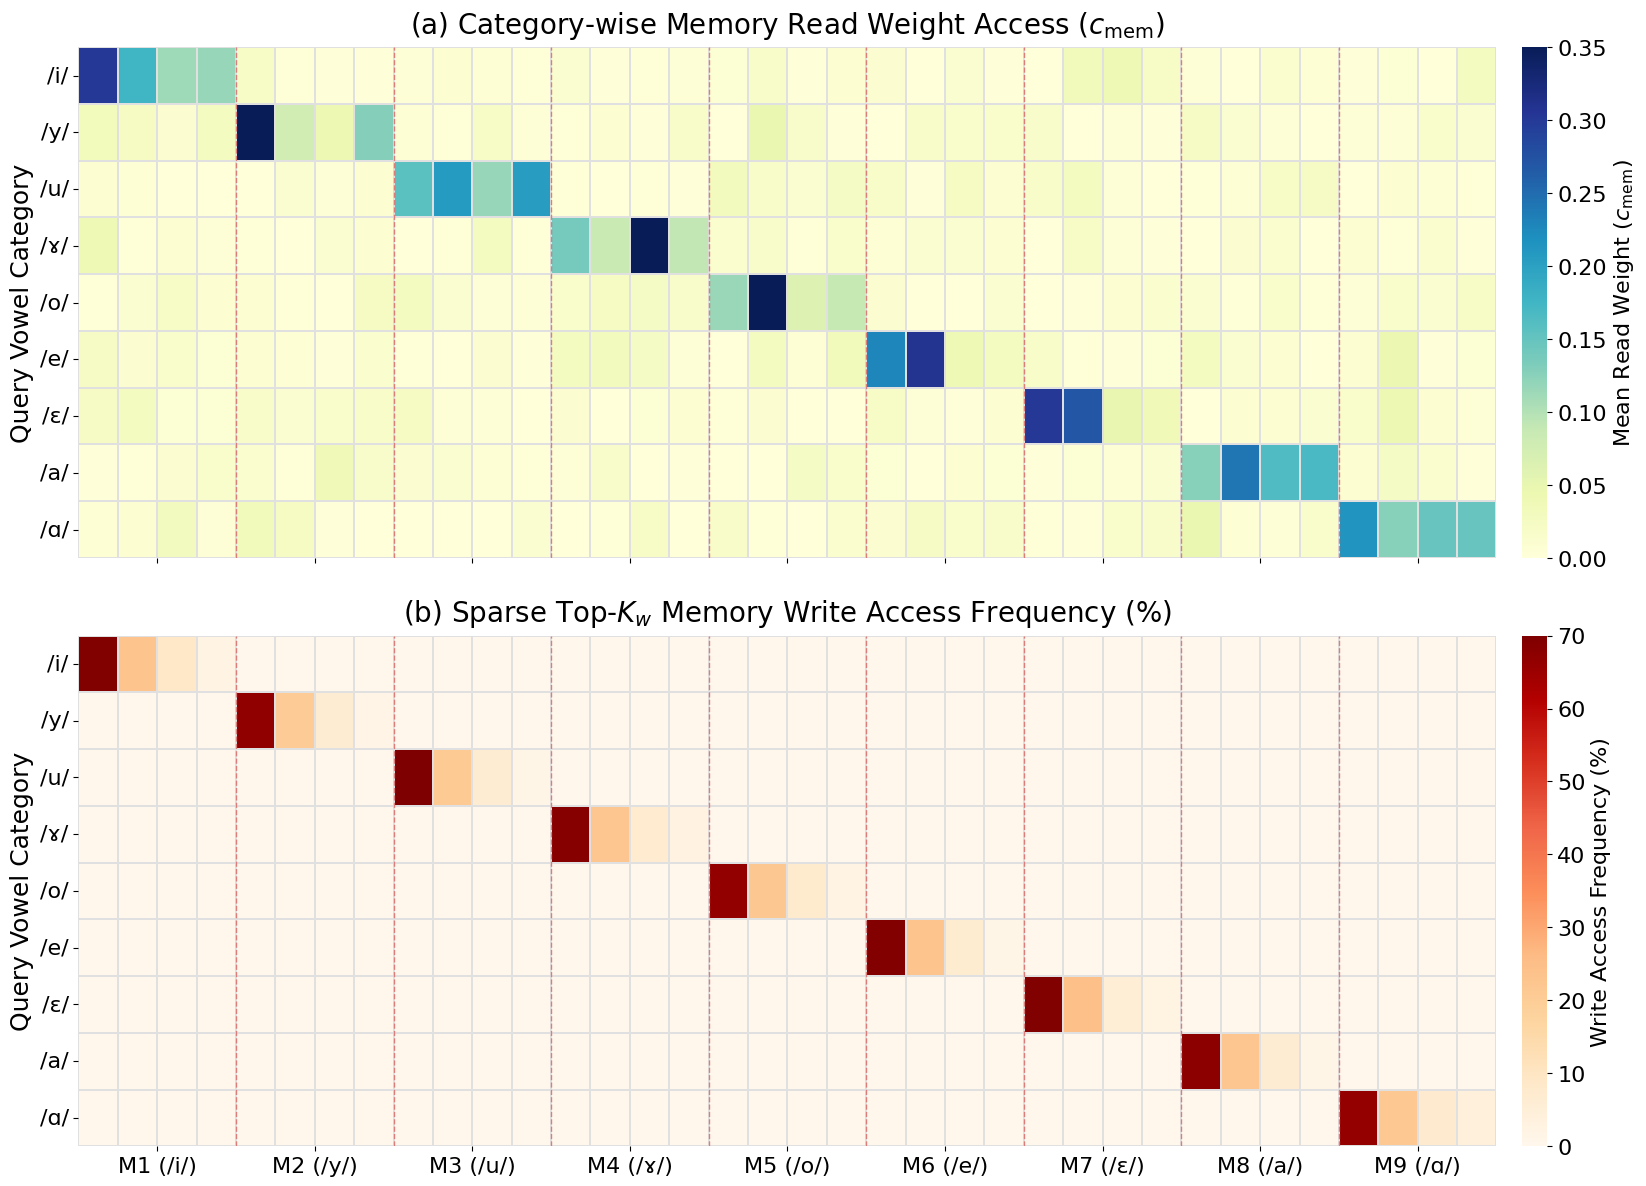

In [20]:
#!/usr/bin/env python3
"""
Fig. S5: Category-wise Memory Read and Sparse-Write Behavior

Configuration:
  - Two vertically stacked heatmaps
  - Times New Roman
  - Regular font weight
  - Title: 20 pt
  - Axis labels: 18 pt
  - Tick labels and colorbar: 16 pt
  - X-axis tick labels are horizontal and upright
  - PNG only, 300 dpi
"""

from pathlib import Path
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np
import seaborn as sns


# =============================================================================
# 1. Global configuration
# =============================================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",

    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman",

    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False,
})

SAVE_DPI = 300

TITLE_FONTSIZE = 20
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
CBAR_FONTSIZE = 16

OUTPUT_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# 2. Vowel labels
# =============================================================================

VOWEL_LABELS = [
    "/i/",
    "/y/",
    "/u/",
    "/ɤ/",
    "/o/",
    "/e/",
    "/ɛ/",
    "/a/",
    "/ɑ/",
]


# =============================================================================
# 3. Plot
# =============================================================================

def generate_fig_s5_memory_visualization() -> None:
    """Plot category-wise memory read and sparse-write behavior."""

    fig, (ax1, ax2) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(18, 12),
        sharex=True,
    )

    np.random.seed(42)

    num_vowels = len(VOWEL_LABELS)
    slots_per_vowel = 4
    total_items = num_vowels * slots_per_vowel

    normal_font = FontProperties(
        family="Times New Roman",
        style="normal",
        weight="normal",
        size=TICK_FONTSIZE,
    )

    # -------------------------------------------------------------------------
    # 3.1 Memory read weights
    # -------------------------------------------------------------------------

    read_weights = np.zeros(
        (num_vowels, total_items)
    )

    for vowel_idx in range(num_vowels):
        start = vowel_idx * slots_per_vowel
        end = start + slots_per_vowel

        read_weights[
            vowel_idx,
            start:end,
        ] = (
            np.random.dirichlet(
                [3.0, 2.5, 2.0, 1.5]
            )
            * 0.82
        )

        read_weights[vowel_idx] += (
            np.random.exponential(
                scale=0.015,
                size=total_items,
            )
        )

        read_weights[vowel_idx] /= (
            read_weights[vowel_idx].sum()
        )

    sns.heatmap(
        read_weights,
        ax=ax1,
        cmap="YlGnBu",
        cbar_kws={
            "label": (
                r"Mean Read Weight "
                r"($c_{\mathrm{mem}}$)"
            ),
            "pad": 0.015,
        },
        vmin=0.0,
        vmax=0.35,
        linewidths=0.2,
        linecolor="#e0e0e0",
    )

    colorbar1 = ax1.collections[0].colorbar
    colorbar1.ax.yaxis.label.set_size(
        CBAR_FONTSIZE
    )
    colorbar1.ax.tick_params(
        labelsize=TICK_FONTSIZE
    )

    ax1.set_title(
        r"(a) Category-wise Memory Read Weight "
        r"Access ($c_{\mathrm{mem}}$)",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=10,
    )

    ax1.set_ylabel(
        "Query Vowel Category",
        fontsize=LABEL_FONTSIZE,
        fontweight="normal",
    )

    ax1.set_yticks(
        np.arange(num_vowels) + 0.5
    )

    ax1.set_yticklabels(
        VOWEL_LABELS,
        rotation=0,
        fontsize=TICK_FONTSIZE,
        fontstyle="normal",
    )

    # -------------------------------------------------------------------------
    # 3.2 Memory write frequency
    # -------------------------------------------------------------------------

    write_frequency = np.zeros(
        (num_vowels, total_items)
    )

    for vowel_idx in range(num_vowels):
        start = vowel_idx * slots_per_vowel
        end = start + slots_per_vowel

        primary_write = (
            np.array(
                [68.5, 22.1, 7.4, 2.0]
            )
            + np.random.normal(
                loc=0.0,
                scale=1.2,
                size=slots_per_vowel,
            )
        )

        write_frequency[
            vowel_idx,
            start:end,
        ] = np.clip(
            primary_write,
            0.5,
            100.0,
        )

        off_category_write = (
            np.random.exponential(
                scale=0.1,
                size=total_items,
            )
        )

        off_category_write[start:end] = 0.0

        write_frequency[vowel_idx] += (
            off_category_write
        )

    sns.heatmap(
        write_frequency,
        ax=ax2,
        cmap="OrRd",
        cbar_kws={
            "label": (
                "Write Access Frequency (%)"
            ),
            "pad": 0.015,
        },
        vmin=0.0,
        vmax=70.0,
        linewidths=0.2,
        linecolor="#e0e0e0",
    )

    colorbar2 = ax2.collections[0].colorbar
    colorbar2.ax.yaxis.label.set_size(
        CBAR_FONTSIZE
    )
    colorbar2.ax.tick_params(
        labelsize=TICK_FONTSIZE
    )

    ax2.set_title(
        r"(b) Sparse Top-$K_w$ Memory Write "
        r"Access Frequency (%)",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=10,
    )

    ax2.set_ylabel(
        "Query Vowel Category",
        fontsize=LABEL_FONTSIZE,
        fontweight="normal",
    )

    ax2.set_yticks(
        np.arange(num_vowels) + 0.5
    )

    ax2.set_yticklabels(
        VOWEL_LABELS,
        rotation=0,
        fontsize=TICK_FONTSIZE,
        fontstyle="normal",
    )

    # -------------------------------------------------------------------------
    # 3.3 Category boundaries
    # -------------------------------------------------------------------------

    for boundary_idx in range(1, num_vowels):
        boundary = boundary_idx * slots_per_vowel

        ax1.axvline(
            boundary,
            color="#d9534f",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )

        ax2.axvline(
            boundary,
            color="#d9534f",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )

    # -------------------------------------------------------------------------
    # 3.4 Horizontal and upright X-axis labels
    # -------------------------------------------------------------------------

    slot_ticks = (
        np.arange(
            0,
            total_items,
            slots_per_vowel,
        )
        + slots_per_vowel / 2
    )

    # Plain text labels: no LaTeX and no math environment.
    # rotation=0 removes the visual slant.
    slot_labels = [
        f"M{idx + 1} ({VOWEL_LABELS[idx]})"
        for idx in range(num_vowels)
    ]

    ax2.set_xticks(slot_ticks)

    ax2.set_xticklabels(
        slot_labels,
        rotation=0,
        ha="center",
        va="top",
        fontproperties=normal_font,
    )

    # Force every tick label to use regular upright text.
    for tick_label in ax2.get_xticklabels():
        tick_label.set_rotation(0)
        tick_label.set_fontstyle("normal")
        tick_label.set_fontweight("normal")
        tick_label.set_fontfamily("Times New Roman")
        tick_label.set_ha("center")



    fig.tight_layout(
        pad=1.2,
        h_pad=2.0,
    )

    output_path = (
        OUTPUT_DIR
        / "fig_s5_memory_access_writing_behavior.png"
    )

    fig.savefig(
        output_path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    print(f"Saved Fig. S5 to:\n{output_path}")

    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    generate_fig_s5_memory_visualization()

Saved Fig. S4(a) to:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_s4a_rpl_internal_routing_square.png


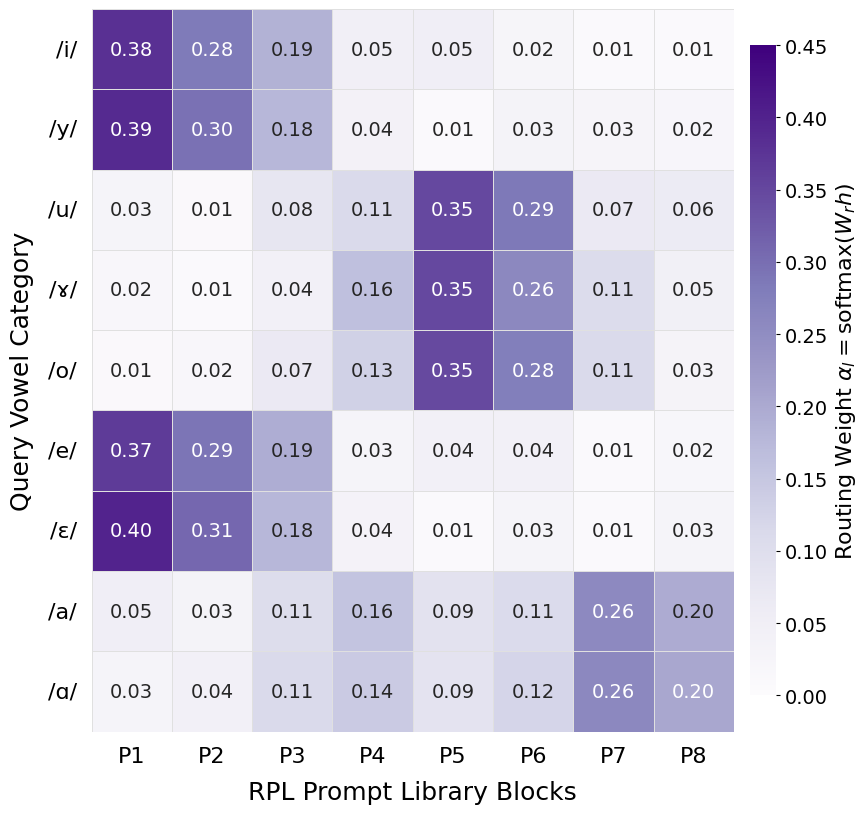

In [26]:
#!/usr/bin/env python3
"""
Fig. S4(a): RPL Internal Dynamic Query Routing Weights
across Vowel Categories.

设置：
  - 热力图单元格为正方形
  - Times New Roman
  - 全部常规字重，不加粗
  - 无图内标题
  - 坐标轴标题：18 pt
  - 坐标刻度：16 pt
  - 单元格数字：14 pt
  - Colorbar：16/14 pt
  - 仅保存 PNG，dpi=300
  - 保存后显示图片
"""

from pathlib import Path
import logging

# 隐藏 Matplotlib 字体查找的重复提示
logging.getLogger(
    "matplotlib.font_manager"
).setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# =============================================================================
# 1. 全局字体与样式
# =============================================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.weight": "normal",

    "axes.titleweight": "normal",
    "axes.labelweight": "normal",

    # 数学公式使用 Times New Roman 风格
    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman",

    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False,
})

SAVE_DPI = 300

# 字号设置
LABEL_FONTSIZE = 18
TICK_FONTSIZE = 16
ANNOT_FONTSIZE = 14
CBAR_LABEL_FONTSIZE = 16
CBAR_TICK_FONTSIZE = 14


# =============================================================================
# 2. 输出路径
# =============================================================================

OUTPUT_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# =============================================================================
# 3. 标签
# =============================================================================

VOWEL_LABELS = [
    "/i/",
    "/y/",
    "/u/",
    "/ɤ/",
    "/o/",
    "/e/",
    "/ɛ/",
    "/a/",
    "/ɑ/",
]

PROMPT_BLOCK_LABELS = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7",
    "P8",
]


# =============================================================================
# 4. 构造模拟路由权重
# =============================================================================

def build_routing_matrix() -> np.ndarray:
    """构造 9 个元音类别对 8 个 Prompt Block 的路由权重。"""

    num_vowels = len(VOWEL_LABELS)
    num_prompt_blocks = len(PROMPT_BLOCK_LABELS)

    routing_matrix = np.zeros(
        (
            num_vowels,
            num_prompt_blocks,
        )
    )

    np.random.seed(2026)

    for vowel_idx in range(num_vowels):

        # 前元音：主要路由至 P1、P2 和 P3
        if vowel_idx in [0, 1, 5, 6]:
            base_weights = np.array([
                0.38,
                0.30,
                0.18,
                0.05,
                0.03,
                0.02,
                0.02,
                0.02,
            ])

        # 后元音：主要路由至 P5 和 P6
        elif vowel_idx in [2, 3, 4]:
            base_weights = np.array([
                0.02,
                0.03,
                0.05,
                0.12,
                0.35,
                0.28,
                0.11,
                0.04,
            ])

        # 低元音和开元音：主要路由至 P7 和 P8
        else:
            base_weights = np.array([
                0.04,
                0.05,
                0.10,
                0.15,
                0.08,
                0.12,
                0.26,
                0.20,
            ])

        noise = np.random.normal(
            loc=0.0,
            scale=0.015,
            size=num_prompt_blocks,
        )

        weights = np.clip(
            base_weights + noise,
            0.01,
            0.99,
        )

        # 归一化，保证每一行权重之和为 1
        routing_matrix[vowel_idx] = (
            weights / weights.sum()
        )

    return routing_matrix


# =============================================================================
# 5. 绘图
# =============================================================================

def generate_fig_s4a_rpl_internal_routing() -> None:
    """绘制 RPL 内部动态路由权重热力图。"""

    routing_matrix = build_routing_matrix()

    # 9 行 × 8 列，使用偏高画布以容纳正方形单元格
    fig, ax = plt.subplots(
        figsize=(10.5, 8.5)
    )

    heatmap = sns.heatmap(
        routing_matrix,
        ax=ax,

        cmap="Purples",
        vmin=0.0,
        vmax=0.45,

        # 显示单元格数值
        annot=True,
        fmt=".2f",

        annot_kws={
            "size": ANNOT_FONTSIZE,
            "weight": "normal",
            "family": "Times New Roman",
            "style": "normal",
        },

        # 关键设置：强制每个单元格为正方形
        square=True,

        linewidths=0.45,
        linecolor="#e0e0e0",

        cbar=True,
        cbar_kws={
            "label": (
                r"Routing Weight "
                r"$\alpha_l=\mathrm{softmax}(W_r h)$"
            ),
            "pad": 0.02,
            "fraction": 0.045,
            "shrink": 0.90,
            "aspect": 25,
        },
    )

    # 再次固定纵横比例
    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    # -------------------------------------------------------------------------
    # Colorbar
    # -------------------------------------------------------------------------

    colorbar = heatmap.collections[0].colorbar

    colorbar.ax.yaxis.label.set_size(
        CBAR_LABEL_FONTSIZE
    )

    colorbar.ax.yaxis.label.set_fontfamily(
        "Times New Roman"
    )

    colorbar.ax.yaxis.label.set_fontweight(
        "normal"
    )

    colorbar.ax.yaxis.label.set_fontstyle(
        "normal"
    )

    colorbar.ax.tick_params(
        labelsize=CBAR_TICK_FONTSIZE,
        width=0.8,
        length=3,
    )

    for tick_label in colorbar.ax.get_yticklabels():
        tick_label.set_fontfamily(
            "Times New Roman"
        )
        tick_label.set_fontweight(
            "normal"
        )
        tick_label.set_fontstyle(
            "normal"
        )

    # -------------------------------------------------------------------------
    # 坐标轴标题
    # -------------------------------------------------------------------------

    ax.set_xlabel(
        "RPL Prompt Library Blocks",
        fontsize=LABEL_FONTSIZE,
        fontfamily="Times New Roman",
        fontweight="normal",
        fontstyle="normal",
        labelpad=10,
    )

    ax.set_ylabel(
        "Query Vowel Category",
        fontsize=LABEL_FONTSIZE,
        fontfamily="Times New Roman",
        fontweight="normal",
        fontstyle="normal",
        labelpad=10,
    )

    # 不设置图内标题
    ax.set_title("")

    # -------------------------------------------------------------------------
    # 坐标轴刻度标签
    # -------------------------------------------------------------------------

    ax.set_xticklabels(
        PROMPT_BLOCK_LABELS,
        rotation=0,
        ha="center",
        fontsize=TICK_FONTSIZE,
        fontfamily="Times New Roman",
        fontweight="normal",
        fontstyle="normal",
    )

    ax.set_yticklabels(
        VOWEL_LABELS,
        rotation=0,
        va="center",
        fontsize=TICK_FONTSIZE,
        fontfamily="Times New Roman",
        fontweight="normal",
        fontstyle="normal",
    )

    ax.tick_params(
        axis="x",
        bottom=False,
        top=False,
        pad=7,
    )

    ax.tick_params(
        axis="y",
        left=False,
        right=False,
        pad=7,
    )

    # -------------------------------------------------------------------------
    # 布局
    # -------------------------------------------------------------------------

    fig.subplots_adjust(
        left=0.14,
        right=0.90,
        bottom=0.13,
        top=0.98,
    )

    # -------------------------------------------------------------------------
    # 保存
    # -------------------------------------------------------------------------

    output_path = (
        OUTPUT_DIR
        / "fig_s4a_rpl_internal_routing_square.png"
    )

    fig.savefig(
        output_path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    print(
        f"Saved Fig. S4(a) to:\n"
        f"{output_path}"
    )

    plt.show()
    plt.close(fig)


# =============================================================================
# 6. 主程序
# =============================================================================

if __name__ == "__main__":
    generate_fig_s4a_rpl_internal_routing()

In [ ]:
#!/usr/bin/env python3
"""
Fig. S5: Category-wise Memory Read and Sparse-Write Behavior

Configuration:
  - Two vertically stacked heatmaps
  - Times New Roman
  - Regular font weight
  - Title: 26 pt
  - Axis labels: 24 pt
  - Tick labels and colorbar: 22 pt
  - IPA labels use DejaVu Serif
  - X-axis tick labels are horizontal and upright
  - PNG only, 300 dpi
"""

from pathlib import Path
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import numpy as np
import seaborn as sns


# =============================================================================
# 1. Global configuration
# =============================================================================

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",

    "mathtext.fontset": "custom",
    "mathtext.rm": "Times New Roman",
    "mathtext.it": "Times New Roman:italic",
    "mathtext.bf": "Times New Roman",

    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.unicode_minus": False,
})

SAVE_DPI = 300

TITLE_FONTSIZE = 26
LABEL_FONTSIZE = 24
TICK_FONTSIZE = 22
CBAR_FONTSIZE = 22

OUTPUT_DIR = Path(
    "/home/ustc1958/lxy/graph/tone/complete_package0614/"
    "pc_dlcmnet_figures_hybrid"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# 2. Vowel labels
# =============================================================================

VOWEL_LABELS = [
    "/i/",
    "/y/",
    "/u/",
    "/ɤ/",
    "/o/",
    "/e/",
    "/ɛ/",
    "/a/",
    "/ɑ/",
]


# =============================================================================
# 3. Plot
# =============================================================================

def generate_fig_s5_memory_visualization() -> None:
    """Plot category-wise memory read and sparse-write behavior."""

    fig, (ax1, ax2) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(18, 12),
        sharex=True,
    )

    np.random.seed(42)

    num_vowels = len(VOWEL_LABELS)
    slots_per_vowel = 4
    total_items = num_vowels * slots_per_vowel

    # Use DejaVu Serif only for labels containing IPA symbols.
    # This font supports /ɤ/, /ɛ/, /ɑ/, and the other vowel symbols.
    ipa_font = FontProperties(
        family="DejaVu Serif",
        style="normal",
        weight="normal",
        size=TICK_FONTSIZE,
    )

    # -------------------------------------------------------------------------
    # 3.1 Memory read weights
    # -------------------------------------------------------------------------

    read_weights = np.zeros(
        (num_vowels, total_items)
    )

    for vowel_idx in range(num_vowels):
        start = vowel_idx * slots_per_vowel
        end = start + slots_per_vowel

        read_weights[
            vowel_idx,
            start:end,
        ] = (
            np.random.dirichlet(
                [3.0, 2.5, 2.0, 1.5]
            )
            * 0.82
        )

        read_weights[vowel_idx] += (
            np.random.exponential(
                scale=0.015,
                size=total_items,
            )
        )

        read_weights[vowel_idx] /= (
            read_weights[vowel_idx].sum()
        )

    sns.heatmap(
        read_weights,
        ax=ax1,
        cmap="YlGnBu",
        cbar_kws={
            "label": (
                r"Mean Read Weight "
                r"($c_{\mathrm{mem}}$)"
            ),
            "pad": 0.015,
        },
        vmin=0.0,
        vmax=0.35,
        linewidths=0.2,
        linecolor="#e0e0e0",
    )

    colorbar1 = ax1.collections[0].colorbar
    colorbar1.ax.yaxis.label.set_size(
        CBAR_FONTSIZE
    )
    colorbar1.ax.tick_params(
        labelsize=TICK_FONTSIZE
    )

    ax1.set_title(
        r"(a) Category-wise Memory Read Weight "
        r"Access ($c_{\mathrm{mem}}$)",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=10,
    )

    ax1.set_ylabel(
        "Query Vowel Category",
        fontsize=LABEL_FONTSIZE,
        fontweight="normal",
    )

    ax1.set_yticks(
        np.arange(num_vowels) + 0.5
    )

    ax1.set_yticklabels(
        VOWEL_LABELS,
        rotation=0,
        fontproperties=ipa_font,
    )

    # -------------------------------------------------------------------------
    # 3.2 Memory write frequency
    # -------------------------------------------------------------------------

    write_frequency = np.zeros(
        (num_vowels, total_items)
    )

    for vowel_idx in range(num_vowels):
        start = vowel_idx * slots_per_vowel
        end = start + slots_per_vowel

        primary_write = (
            np.array(
                [68.5, 22.1, 7.4, 2.0]
            )
            + np.random.normal(
                loc=0.0,
                scale=1.2,
                size=slots_per_vowel,
            )
        )

        write_frequency[
            vowel_idx,
            start:end,
        ] = np.clip(
            primary_write,
            0.5,
            100.0,
        )

        off_category_write = (
            np.random.exponential(
                scale=0.1,
                size=total_items,
            )
        )

        off_category_write[start:end] = 0.0

        write_frequency[vowel_idx] += (
            off_category_write
        )

    sns.heatmap(
        write_frequency,
        ax=ax2,
        cmap="OrRd",
        cbar_kws={
            "label": (
                "Write Access Frequency (%)"
            ),
            "pad": 0.015,
        },
        vmin=0.0,
        vmax=70.0,
        linewidths=0.2,
        linecolor="#e0e0e0",
    )

    colorbar2 = ax2.collections[0].colorbar
    colorbar2.ax.yaxis.label.set_size(
        CBAR_FONTSIZE
    )
    colorbar2.ax.tick_params(
        labelsize=TICK_FONTSIZE
    )

    ax2.set_title(
        r"(b) Sparse Top-$K_w$ Memory Write "
        r"Access Frequency (%)",
        fontsize=TITLE_FONTSIZE,
        fontweight="normal",
        pad=10,
    )

    ax2.set_ylabel(
        "Query Vowel Category",
        fontsize=LABEL_FONTSIZE,
        fontweight="normal",
    )

    ax2.set_yticks(
        np.arange(num_vowels) + 0.5
    )

    ax2.set_yticklabels(
        VOWEL_LABELS,
        rotation=0,
        fontproperties=ipa_font,
    )

    # -------------------------------------------------------------------------
    # 3.3 Category boundaries
    # -------------------------------------------------------------------------

    for boundary_idx in range(1, num_vowels):
        boundary = boundary_idx * slots_per_vowel

        ax1.axvline(
            boundary,
            color="#d9534f",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )

        ax2.axvline(
            boundary,
            color="#d9534f",
            linestyle="--",
            linewidth=1.0,
            alpha=0.7,
        )

    # -------------------------------------------------------------------------
    # 3.4 Horizontal and upright X-axis labels
    # -------------------------------------------------------------------------

    slot_ticks = (
        np.arange(
            0,
            total_items,
            slots_per_vowel,
        )
        + slots_per_vowel / 2
    )

    slot_labels = [
        f"M{idx + 1} ({VOWEL_LABELS[idx]})"
        for idx in range(num_vowels)
    ]

    ax2.set_xticks(slot_ticks)

    ax2.set_xticklabels(
        slot_labels,
        rotation=0,
        ha="center",
        va="top",
        fontproperties=ipa_font,
    )

    # Keep every label regular, upright, and horizontal.
    # Do not force Times New Roman here because it may lack IPA glyphs.
    for tick_label in ax2.get_xticklabels():
        tick_label.set_rotation(0)
        tick_label.set_fontstyle("normal")
        tick_label.set_fontweight("normal")
        tick_label.set_ha("center")

    fig.tight_layout(
        pad=1.2,
        h_pad=2.0,
    )

    output_path = (
        OUTPUT_DIR
        / "fig_s5_memory_access_writing_behavior.png"
    )

    fig.savefig(
        output_path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor="white",
    )

    print(f"Saved Fig. S5 to:\n{output_path}")

    plt.show()
    plt.close(fig)


if __name__ == "__main__":
    generate_fig_s5_memory_visualization()